In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, TimeDistributed, Reshape, Lambda, Concatenate
import tensorflow as tf
import json
import glob

# Load all JSON files
json_files = glob.glob('*.json')
all_samples = []

for file in json_files:
    with open(file, "r") as f:
        raw = json.load(f)
    
    if isinstance(raw, list):
        for session in raw:
            samples = session['samples']
            all_samples.extend(samples)
    else:
        samples = raw['samples']
        all_samples.extend(samples)

print(f"Total samples: {len(all_samples)}")
# Extract samples
df_data = pd.DataFrame(all_samples)
df = pd.json_normalize(all_samples)

print(df_data.columns.tolist())
df_data.set_index('time', inplace=True)
print(df_data.head())

Total samples: 124696
['time', 'env', 'trial', 'user', 'pois']
       env  trial                                               user  \
time                                                                   
9303.7   D      1  {'x': -0.009576471146144114, 'z': -0.020370276...   
9354.3   D      1  {'x': -0.008997241417596447, 'z': -0.020436469...   
9403.6   D      1  {'x': -0.00861159972056974, 'z': -0.0201739579...   
9455.3   D      1  {'x': -0.008545451095556864, 'z': -0.020026871...   
9503.7   D      1  {'x': -0.008380717327506847, 'z': -0.019520434...   

                                                     pois  
time                                                       
9303.7  [{'distance': 1.253272932899953, 'angle': 1.21...  
9354.3  [{'distance': 1.253799755449084, 'angle': 1.21...  
9403.6  [{'distance': 1.2542495012332384, 'angle': 1.2...  
9455.3  [{'distance': 1.2543596089658189, 'angle': 1.2...  
9503.7  [{'distance': 1.2546791690551167, 'angle': 1.2...  


In [3]:
# Filter valid samples
df_data = df_data[df_data['user'].apply(lambda x: isinstance(x, dict)) & df_data['pois'].apply(lambda x: isinstance(x, list))]
print(f"Filtered data length: {len(df_data)}")

Filtered data length: 124696


In [4]:
print(df_data['user'].apply(type).value_counts())
print(df_data['pois'].apply(type).value_counts())

user
<class 'dict'>    124696
Name: count, dtype: int64
pois
<class 'list'>    124696
Name: count, dtype: int64


In [5]:
print(df_data.columns)

Index(['env', 'trial', 'user', 'pois'], dtype='object')


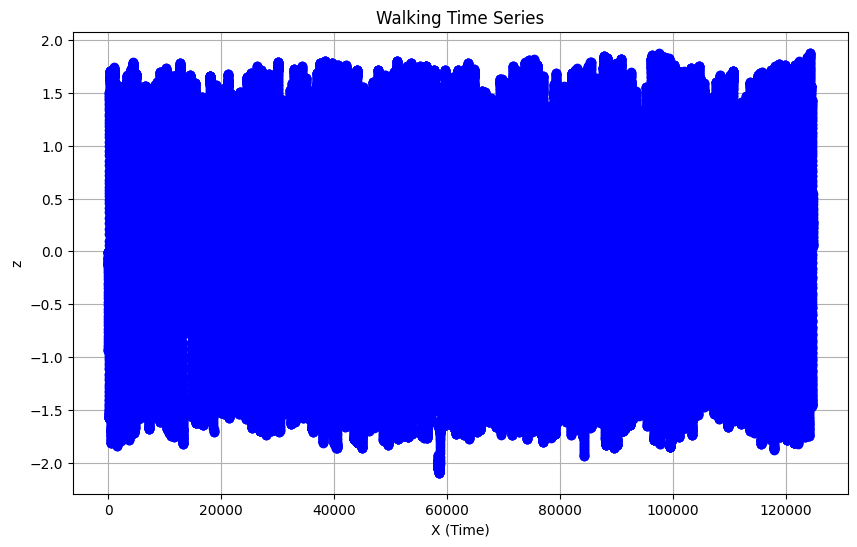

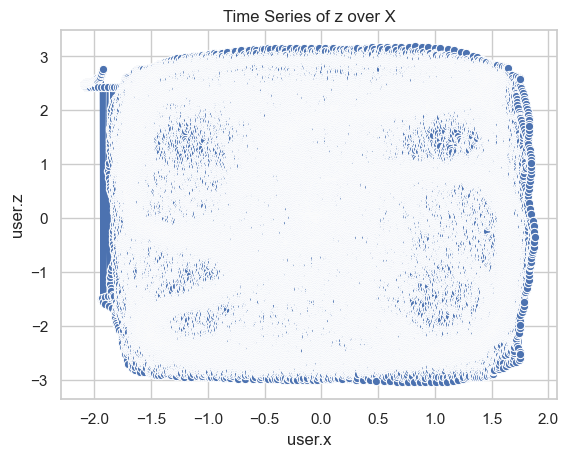

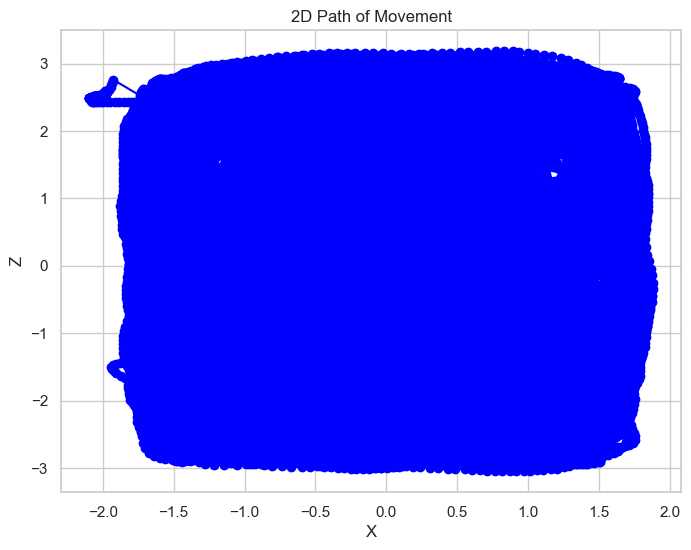

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(df['user.x'], marker='o', linestyle='-',color='blue')
plt.title('Walking Time Series')
plt.xlabel('X (Time)')
plt.ylabel('z')
plt.grid(True)
plt.show()

sns.set(style="whitegrid")
sns.lineplot(x='user.x', y='user.z', data=df, marker='o')
plt.title('Time Series of z over X')
plt.show()

fig = px.line(df, x='user.x', y='user.z', title='Interactive Time Series of z over X')

fig.update_layout(
    xaxis_title='X (Time)',
    yaxis_title='z',
    template='plotly_white'
)

fig.show()

# Plot path
plt.figure(figsize=(8, 6))
plt.plot(df['user.x'], df['user.z'], marker='o', linestyle='-', color='blue')
plt.title('2D Path of Movement')
plt.xlabel('X')
plt.ylabel('Z')
plt.grid(True)
plt.show()

plt.show()

In [7]:
# Flatten user
print(f"df_data len: {len(df_data)}")
user_df = pd.json_normalize(df_data['user'])
user_df.columns = ['x', 'z', 'vx', 'vz', 'yaw']
# Rotate velocities to local coordinate frame
user_df['vx_local'] = user_df['vx'] * np.cos(user_df['yaw']) + user_df['vz'] * np.sin(user_df['yaw'])
user_df['vz_local'] = -user_df['vx'] * np.sin(user_df['yaw']) + user_df['vz'] * np.cos(user_df['yaw'])
user_df = user_df[['x', 'z', 'vx_local', 'vz_local', 'yaw']]
user_df.columns = ['x', 'z', 'vx', 'vz', 'yaw']
print(f"user_df len: {len(user_df)}")
# user_df['env'] = data['env']
# user_df['trial'] = data['trial']
# user_df['time'] = data['time']

df_data len: 124696
user_df len: 124696


In [8]:
# Flatten POIs with relative angles

def flatten_pois_safe(row, max_pois=5):
    pois_list = row
    
    # Handle bad rows
    if not isinstance(pois_list, list):
        return {f'poi_{i}_{k}': 0 for i in range(max_pois) for k in ['dist', 'angle']}
    
    # Sort by distance
    pois_list = sorted(pois_list, key=lambda x: x['distance'])
    
    flat = {}
    
    for i in range(max_pois):
        if i < len(pois_list):
            flat[f'poi_{i}_dist'] = pois_list[i]['distance']
            # Already stored as a relative forward-facing angle
            flat[f'poi_{i}_angle'] = np.arctan2(np.sin(pois_list[i]['angle']), np.cos(pois_list[i]['angle']))
        else:
            flat[f'poi_{i}_dist'] = 0
            flat[f'poi_{i}_angle'] = 0
    
    return flat

pois_df = pd.DataFrame([flatten_pois_safe(p) for p in df_data['pois']])


In [9]:
# Flatten user
user_df = pd.json_normalize(df_data['user'])
user_df.columns = ['x', 'z', 'vx', 'vz', 'yaw']
# Rotate velocities to local coordinate frame
user_df['vx_local'] = user_df['vx'] * np.cos(user_df['yaw']) + user_df['vz'] * np.sin(user_df['yaw'])
user_df['vz_local'] = -user_df['vx'] * np.sin(user_df['yaw']) + user_df['vz'] * np.cos(user_df['yaw'])
user_df = user_df[['x', 'z', 'vx_local', 'vz_local', 'yaw']]
user_df.columns = ['x', 'z', 'vx', 'vz', 'yaw']

In [10]:
print(type(df_data['pois'].iloc[0]))
print(df_data['pois'].iloc[0])

<class 'list'>
[{'distance': 1.253272932899953, 'angle': 1.2139552903169568}, {'distance': 1.9673928533215423, 'angle': 0.7034945170166381}, {'distance': 2.309717385714271, 'angle': 0.848629759227636}, {'distance': 2.525997930279281, 'angle': 0.5762463016909609}, {'distance': 2.9614143598956626, 'angle': 0.07653475677376848}]


In [11]:
print(pois_df.head())

   poi_0_dist  poi_0_angle  poi_1_dist  poi_1_angle  poi_2_dist  poi_2_angle  \
0    1.253273     1.213955    1.967393     0.703495    2.309717     0.848630   
1    1.253800     1.213629    1.967730     0.703316    2.310120     0.848353   
2    1.254250     1.212861    1.968183     0.702748    2.310584     0.847731   
3    1.254360     1.212321    1.968337     0.702289    2.310729     0.847262   
4    1.254679     1.208206    1.968824     0.698481    2.311180     0.843412   

   poi_3_dist  poi_3_angle  poi_4_dist  poi_4_angle  
0    2.525998     0.576246    2.961414     0.076535  
1    2.526272     0.576077    2.961401     0.077904  
2    2.526707     0.575538    2.961698     0.078139  
3    2.526866     0.575099    2.961850     0.077983  
4    2.527376     0.571377    2.962370     0.076215  


In [12]:
# Combine (use index as time)
df_final = pd.concat([
    df_data.reset_index()[['time', 'env', 'trial']].reset_index(drop=True),
    user_df.reset_index(drop=True),
    pois_df.reset_index(drop=True)
], axis=1)

df_final = df_final.dropna()

print(f"Lengths: df_data {len(df_data)}, user_df {len(user_df)}, pois_df {len(pois_df)}, df_final {len(df_final)}")
print(df_final['env'].value_counts())
print(df.head())

Lengths: df_data 124696, user_df 124696, pois_df 124696, df_final 124696
env
D    45835
C    30008
B    24793
A    24060
Name: count, dtype: int64
     time env  trial                                               pois  \
0  9303.7   D      1  [{'distance': 1.253272932899953, 'angle': 1.21...   
1  9354.3   D      1  [{'distance': 1.253799755449084, 'angle': 1.21...   
2  9403.6   D      1  [{'distance': 1.2542495012332384, 'angle': 1.2...   
3  9455.3   D      1  [{'distance': 1.2543596089658189, 'angle': 1.2...   
4  9503.7   D      1  [{'distance': 1.2546791690551167, 'angle': 1.2...   

     user.x    user.z   user.vx   user.vz  user.yaw  
0 -0.009576 -0.020370  0.014867 -0.005156  0.028285  
1 -0.008997 -0.020436  0.011447 -0.001308  0.028859  
2 -0.008612 -0.020174  0.007822  0.005325  0.029549  
3 -0.008545 -0.020027  0.001279  0.002845  0.030001  
4 -0.008381 -0.019520  0.003404  0.010464  0.033816  


In [13]:
# Splitting by environment
test_env = 'A'

train_df = df_final[df_final['env'] != test_env]
test_df  = df_final[df_final['env'] == test_env]

In [14]:
print(df_final['env'].value_counts())

env
D    45835
C    30008
B    24793
A    24060
Name: count, dtype: int64


In [15]:
# # Scaling the data for LSTM
# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(df)

In [16]:
# Create sequences for LSTM
def create_sequences_grouped(df, seq_length=10):
    X, y = [], []
    
    for _, group in df.groupby(['env', 'trial']):
        
        group = group.reset_index(drop=True)
        
        # Drop non-feature columns
        features = group.drop(columns=['env', 'trial', 'time']).values
        
        for i in range(len(features) - seq_length):
            X.append(features[i:i+seq_length])
            y.append(features[i+seq_length][:2])  # predict x, z
    
    return np.array(X), np.array(y)

In [17]:
# Create sequences
SEQ_LENGTH = 50
X_train, y_train = create_sequences_grouped(train_df, seq_length=SEQ_LENGTH)
X_test, y_test = create_sequences_grouped(test_df, seq_length=SEQ_LENGTH)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (98386, 50, 15), y_train shape: (98386, 2)
X_test shape: (23310, 50, 15), y_test shape: (23310, 2)


In [18]:
# Build an LSTM model that encodes each POI via a shared MLP and mean-pools POI context
inputs = Input(shape=(SEQ_LENGTH, 15), name='trajectory_input')

# Split user trajectory and POI features
user_features = Lambda(lambda x: x[:, :, :5], name='user_features')(inputs)
poi_features = Lambda(lambda x: x[:, :, 5:], name='poi_raw')(inputs)
poi_reshaped = Reshape((SEQ_LENGTH, 5, 2), name='poi_reshape')(poi_features)

# Shared MLP for each POI (32-unit -> 16-unit as per paper methodology)
poi_encoded = TimeDistributed(Dense(32, activation='relu'), name='poi_mlp_1')(poi_reshaped)
poi_encoded = TimeDistributed(Dense(16, activation='relu'), name='poi_mlp_2')(poi_encoded)

# Mean pool across the 5 POIs to produce a POI context vector per time step
poi_context = Lambda(lambda x: tf.reduce_mean(x, axis=2), name='poi_mean_pool')(poi_encoded)

# Concatenate the POI context with user trajectory features
fused = Concatenate(axis=-1, name='trajectory_poi_fusion')([user_features, poi_context])

# Process fused sequence through LSTM stack
x = LSTM(64, return_sequences=True, name='lstm_1')(fused)
x = LSTM(64, name='lstm_2')(x)
x = Dropout(0.3, name='dropout')(x)
outputs = Dense(2, name='position_output')(x)

# Build model
model = tf.keras.Model(inputs=inputs, outputs=outputs, name='poicontext_lstm')

model.summary()


Model: "poicontext_lstm"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 trajectory_input (InputLay  [(None, 50, 15)]             0         []                            
 er)                                                                                              
                                                                                                  
 poi_raw (Lambda)            (None, 50, 10)               0         ['trajectory_input[0][0]']    
                                                                                                  
 poi_reshape (Reshape)       (None, 50, 5, 2)             0         ['poi_raw[0][0]']             
                                                                                                  
 poi_mlp_1 (TimeDistributed  (None, 50, 5, 32)            96        ['poi_reshape[0

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

In [20]:
# Train the model
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20


3075/3075 [==============================] - 145s 45ms/step - loss: 0.0675 - mae: 0.1546 - val_loss: 0.0289 - val_mae: 0.0480
Epoch 2/20
3075/3075 [==============================] - 130s 42ms/step - loss: 0.0478 - mae: 0.1335 - val_loss: 0.0287 - val_mae: 0.0477
Epoch 3/20
3075/3075 [==============================] - 126s 41ms/step - loss: 0.0466 - mae: 0.1310 - val_loss: 0.0291 - val_mae: 0.0521
Epoch 4/20
3075/3075 [==============================] - 133s 43ms/step - loss: 0.0461 - mae: 0.1299 - val_loss: 0.0278 - val_mae: 0.0442
Epoch 5/20
3075/3075 [==============================] - 142s 46ms/step - loss: 0.0457 - mae: 0.1289 - val_loss: 0.0296 - val_mae: 0.0611
Epoch 6/20
3075/3075 [==============================] - 165s 54ms/step - loss: 0.0449 - mae: 0.1287 - val_loss: 0.0270 - val_mae: 0.0585
Epoch 7/20
3075/3075 [==============================] - 146s 47ms/step - loss: 0.0427 - mae: 0.1286 - val_loss: 0.0230 - val_mae: 0.0425
Epoch 8/20
3075/3075 [=================

In [21]:
# make predictions
preds = model.predict(X_test)

729/729 [==============================] - 10s 11ms/step


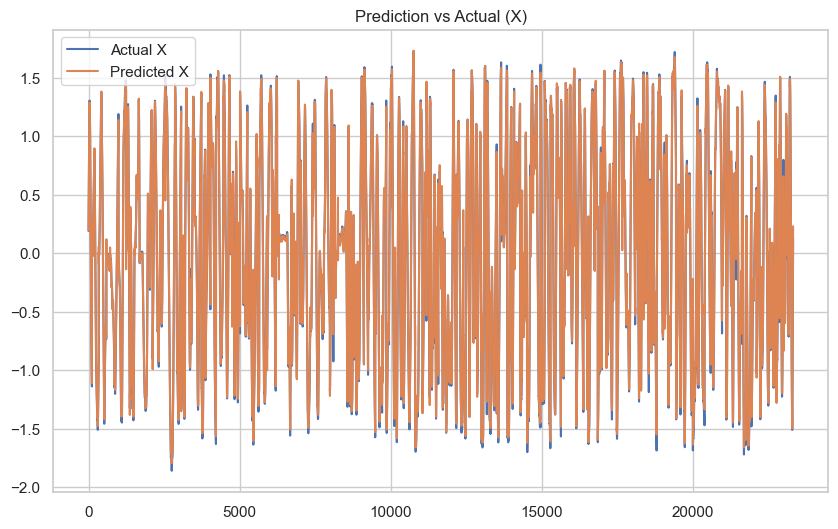

In [22]:
# Plot actual vs predicted for X
plt.figure(figsize=(10,6))

# Actual
plt.plot(y_test[:,0], label='Actual X')
# Predicted
plt.plot(preds[:,0], label='Predicted X')

plt.legend()
plt.title("Prediction vs Actual (X)")
plt.show()

In [23]:
# Select one trial from environment D
selected_trial = test_df['trial'].unique()[0]
test_df_single = test_df[test_df['trial'] == selected_trial]

# Create sequences for this single trial
X_test_single, y_test_single = create_sequences_grouped(test_df_single, seq_length=SEQ_LENGTH)
preds_single = model.predict(X_test_single)

# Get actual positions
actual_x = test_df_single['x'].values
actual_z = test_df_single['z'].values

# Current positions
current_x = X_test_single[:, -1, 0]
current_z = X_test_single[:, -1, 1]

# Predicted next
pred_x = preds_single[:, 0]
pred_z = preds_single[:, 1]

# Calculate POI positions (at the user's position when closest to each POI)
poi_x_list = []
poi_z_list = []
for poi in range(5):
    dist_col = f'poi_{poi}_dist'
    min_dist_idx = test_df_single[dist_col].idxmin()
    poi_x = test_df_single.loc[min_dist_idx, 'x']
    poi_z = test_df_single.loc[min_dist_idx, 'z']
    poi_x_list.append(poi_x)
    poi_z_list.append(poi_z)

# Plot interactive map
import plotly.graph_objects as go

fig = go.Figure()

# Add actual path
fig.add_trace(go.Scatter(x=actual_x, y=actual_z, mode='lines+markers', name='Actual Path', 
                         line=dict(color='blue', width=2), marker=dict(size=4)))

# Add start and end markers
fig.add_trace(go.Scatter(x=[actual_x[0]], y=[actual_z[0]], mode='markers', name='Start', 
                         marker=dict(color='green', size=10, symbol='star')))
fig.add_trace(go.Scatter(x=[actual_x[-1]], y=[actual_z[-1]], mode='markers', name='End', 
                         marker=dict(color='purple', size=10, symbol='star')))

# Add predicted steps
for i in range(len(current_x)):
    fig.add_trace(go.Scatter(x=[current_x[i], pred_x[i]], y=[current_z[i], pred_z[i]], 
                             mode='lines', name='Predicted Step' if i == 0 else '', 
                             line=dict(color='red', width=2, dash='dash'), showlegend=i==0))

# Add POIs
fig.add_trace(go.Scatter(x=poi_x_list, y=poi_z_list, mode='markers', name='POIs', 
                         marker=dict(color='green', size=6, symbol='x')))

fig.update_layout(
    title=f'Map of Actual and Predicted User Walking Paths (Environment D, Trial {selected_trial})',
    xaxis_title='X Position',
    yaxis_title='Z Position',
    width=800,
    height=600
)

fig.show()

64/64 [==============================] - 1s 23ms/step


In [24]:
# Evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_x = mean_absolute_error(y_test[:, 0], preds[:, 0])
mae_z = mean_absolute_error(y_test[:, 1], preds[:, 1])
rmse_x = np.sqrt(mean_squared_error(y_test[:, 0], preds[:, 0]))
rmse_z = np.sqrt(mean_squared_error(y_test[:, 1], preds[:, 1]))

print(f"Test MAE - X: {mae_x:.4f}, Z: {mae_z:.4f}")
print(f"Test RMSE - X: {rmse_x:.4f}, Z: {rmse_z:.4f}")

# Overall MAE and RMSE
mae_overall = (mae_x + mae_z) / 2
rmse_overall = (rmse_x + rmse_z) / 2
print(f"Overall MAE: {mae_overall:.4f}, RMSE: {rmse_overall:.4f}")

Test MAE - X: 0.0262, Z: 0.0422
Test RMSE - X: 0.0923, Z: 0.1894
Overall MAE: 0.0342, RMSE: 0.1409


POI Distance Statistics:
          poi_0_dist     poi_1_dist     poi_2_dist     poi_3_dist  \
count  124696.000000  124696.000000  124696.000000  124696.000000   
mean        1.768782       1.888825       1.673824       1.397782   
std         1.072724       1.460316       1.715956       1.892210   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.975733       0.000000       0.000000       0.000000   
50%         1.498347       1.943795       1.807432       0.000000   
75%         2.267092       2.851407       3.076783       3.144517   
max         6.266718       6.181635       6.536422       6.356879   

          poi_4_dist  
count  124696.000000  
mean        0.912138  
std         1.800514  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         6.431860  

POI Angle Statistics:
         poi_0_angle    poi_1_angle    poi_2_angle    poi_3_angle  \
count  124696.000000  124696.000000  124696.000000  12

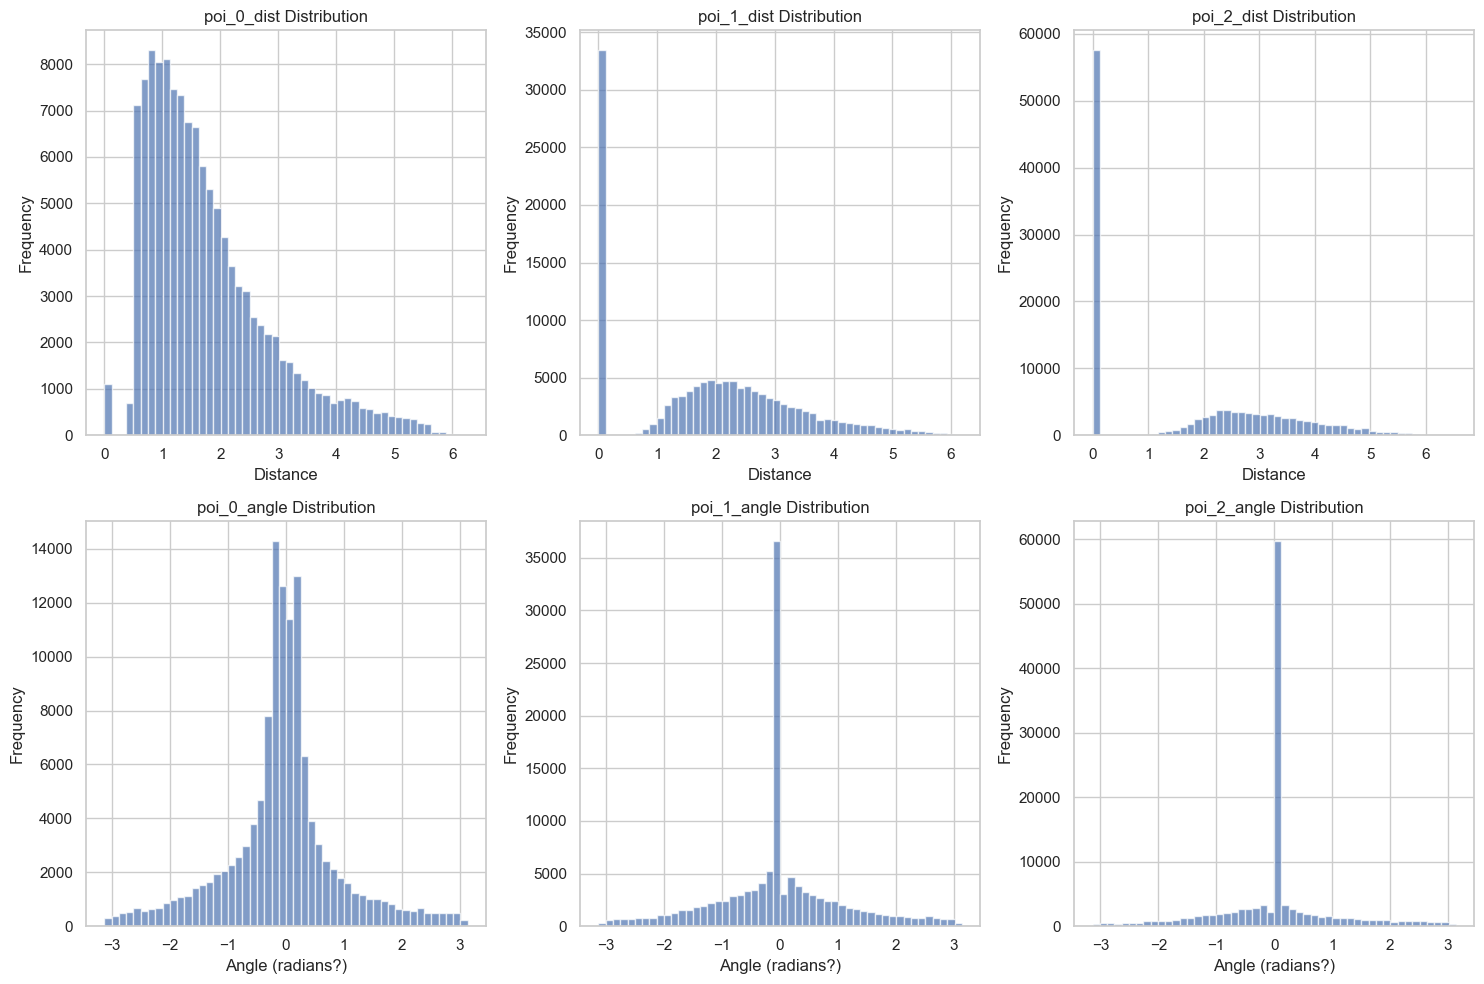


Sample angles: 0    1.213955
1    1.213629
2    1.212861
3    1.212321
4    1.208206
Name: poi_0_angle, dtype: float64
Yaw range: -3.142 to 3.142
Angle range: -3.133 to 3.134


In [25]:
# Analyze POI data validity
import matplotlib.pyplot as plt

poi_cols = [col for col in df_final.columns if 'poi' in col and 'dist' in col]
angle_cols = [col for col in df_final.columns if 'poi' in col and 'angle' in col]

print("POI Distance Statistics:")
print(df_final[poi_cols].describe())

print("\nPOI Angle Statistics:")
print(df_final[angle_cols].describe())

# Check correlation between yaw and angles
yaw_col = 'yaw'
corrs_yaw = df_final[[yaw_col] + angle_cols].corr()
print(f"\nCorrelations between yaw and POI angles:\n{corrs_yaw[yaw_col]}")

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(poi_cols[:3]):
    axes[0, i].hist(df_final[col], bins=50, alpha=0.7)
    axes[0, i].set_title(f'{col} Distribution')
    axes[0, i].set_xlabel('Distance')
    axes[0, i].set_ylabel('Frequency')

for i, col in enumerate(angle_cols[:3]):
    axes[1, i].hist(df_final[col], bins=50, alpha=0.7)
    axes[1, i].set_title(f'{col} Distribution')
    axes[1, i].set_xlabel('Angle (radians?)')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check if angles are in degrees or radians
print(f"\nSample angles: {df_final[angle_cols[0]].head()}")
print(f"Yaw range: {df_final[yaw_col].min():.3f} to {df_final[yaw_col].max():.3f}")
print(f"Angle range: {df_final[angle_cols[0]].min():.3f} to {df_final[angle_cols[0]].max():.3f}")

In [124]:
# Check correlations between POI features and target positions
poi_cols = [col for col in df_final.columns if 'poi' in col]
target_cols = ['x', 'z']

corrs = df_final[poi_cols + target_cols].corr()
print("Correlations between POI features and positions:")
print(corrs.loc[poi_cols, target_cols])

# Also check with velocities and yaw
all_features = ['x', 'z', 'vx', 'vz', 'yaw'] + poi_cols
corrs_full = df_final[all_features].corr()
print("\nFull feature correlations with x and z:")
print(corrs_full.loc[all_features, ['x', 'z']])

# Check if POI features have predictive power
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Simple linear regression for each POI feature to x
for col in poi_cols:
    X_feat = df_final[[col]]
    y_x = df_final['x']
    model_x = LinearRegression().fit(X_feat, y_x)
    r2_x = r2_score(y_x, model_x.predict(X_feat))
    
    y_z = df_final['z']
    model_z = LinearRegression().fit(X_feat, y_z)
    r2_z = r2_score(y_z, model_z.predict(X_feat))
    
    print(f"{col}: R² with x = {r2_x:.4f}, with z = {r2_z:.4f}")

Correlations between POI features and positions:
                    x         z
poi_0_dist   0.034482 -0.005472
poi_0_angle -0.021887 -0.076618
poi_1_dist   0.046146 -0.146342
poi_1_angle  0.113713 -0.041000
poi_2_dist   0.062153 -0.076536
poi_2_angle  0.114299 -0.067094
poi_3_dist  -0.048871  0.009022
poi_3_angle  0.050207 -0.036259
poi_4_dist  -0.127206  0.009964
poi_4_angle  0.003297 -0.050599

Full feature correlations with x and z:
                    x         z
x            1.000000  0.084092
z            0.084092  1.000000
vx           0.018804 -0.035957
vz           0.038105  0.018591
yaw          0.258354  0.026568
poi_0_dist   0.034482 -0.005472
poi_0_angle -0.021887 -0.076618
poi_1_dist   0.046146 -0.146342
poi_1_angle  0.113713 -0.041000
poi_2_dist   0.062153 -0.076536
poi_2_angle  0.114299 -0.067094
poi_3_dist  -0.048871  0.009022
poi_3_angle  0.050207 -0.036259
poi_4_dist  -0.127206  0.009964
poi_4_angle  0.003297 -0.050599
poi_0_dist: R² with x = 0.0012, with z = 0.000

In [27]:
# Train a baseline model without POI features
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Features without POIs: x, z, vx, vz, yaw (5 features)
X_train_no_poi = X_train[:, :, :5]
X_test_no_poi = X_test[:, :, :5]

model_no_poi = Sequential([
    LSTM(64, input_shape=(SEQ_LENGTH, 5), return_sequences=True),
    LSTM(64, input_shape=(SEQ_LENGTH, 5)),
    Dropout(0.3),
    Dense(2)
])

model_no_poi.compile(optimizer='adam', loss='mse')

print("Training model without POI features...")
history_no_poi = model_no_poi.fit(
    X_train_no_poi, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_no_poi, y_test),
    verbose=0
)

preds_no_poi = model_no_poi.predict(X_test_no_poi)

mae_x_no_poi = mean_absolute_error(y_test[:, 0], preds_no_poi[:, 0])
mae_z_no_poi = mean_absolute_error(y_test[:, 1], preds_no_poi[:, 1])
rmse_x_no_poi = np.sqrt(mean_squared_error(y_test[:, 0], preds_no_poi[:, 0]))
rmse_z_no_poi = np.sqrt(mean_squared_error(y_test[:, 1], preds_no_poi[:, 1]))

print(f"Model without POIs - MAE X: {mae_x_no_poi:.4f}, Z: {mae_z_no_poi:.4f}")
print(f"Model without POIs - RMSE X: {rmse_x_no_poi:.4f}, Z: {rmse_z_no_poi:.4f}")

print(f"\nComparison:")
print(f"With POIs - MAE: {mae_overall:.4f}, RMSE: {rmse_overall:.4f}")
print(f"Without POIs - MAE: {(mae_x_no_poi + mae_z_no_poi)/2:.4f}, RMSE: {(rmse_x_no_poi + rmse_z_no_poi)/2:.4f}")

# Check if POIs improve performance
if mae_overall < (mae_x_no_poi + mae_z_no_poi)/2:
    print("POI features improve model performance.")
else:
    print("POI features do not improve (or worsen) model performance.")

Training model without POI features...
729/729 [==============================] - 6s 8ms/step
Model without POIs - MAE X: 0.0341, Z: 0.0400
Model without POIs - RMSE X: 0.1050, Z: 0.2101

Comparison:
With POIs - MAE: 0.0342, RMSE: 0.1409
Without POIs - MAE: 0.0370, RMSE: 0.1575
POI features improve model performance.
